# SADGS — training and submission pipeline

This notebook is **glue only**. Every step is a function in `pipeline/`:

| File | Responsibility |
|---|---|
| `pipeline/config.py` | every parameter, in one place |
| `pipeline/env.py` | GPU check, dependency install, RAM/VRAM tracking and cleanup |
| `pipeline/data.py` | download data, discover scenes, data profile |
| `pipeline/trainer.py` | SADGS training loop with live scoring |
| `pipeline/score.py` | LPIPS / SSIM / PSNR and `Score = 0.4(1−LPIPS) + 0.3·SSIM + 0.3·PSNR_norm` |
| `pipeline/submission.py` | render the test poses → `submission.zip` + format check |
| `pipeline/report.py` | comparison tables and plots |
| `pipeline/deliver.py` | package results and download them |
| `pipeline/run.py` | wires it together (`setup → load_data → smoke_test → run_all → analytics → finish`) |

**Runtime → Change runtime type → T4 GPU**, then **Runtime → Run all**.

## 0 — Get the code

The first install takes ~3–5 minutes to build the three CUDA submodules; later sessions skip it via the `/content/.deps_ok` flag.

In [1]:
REPO_URL = "https://github.com/KietAnhCS/BTS3D-GS.git"
REPO_DIR = "/content/BTS3D-GS"
REPO_SUBDIR = None   # code nam ngay o root cua repo tren, khong co thu muc con

import os, sys

if os.path.isdir("pipeline"):
    TARGET_DIR = os.getcwd()                 # da o san trong repo (vd chay local)
else:
    if not os.path.isdir(REPO_DIR):
        !git clone -q {REPO_URL} {REPO_DIR}
    else:
        !git -C {REPO_DIR} pull -q
    TARGET_DIR = os.path.join(REPO_DIR, REPO_SUBDIR) if REPO_SUBDIR else REPO_DIR

%cd {TARGET_DIR}
sys.path.insert(0, TARGET_DIR)


/content/BTS3D-GS


## 1 — Check the GPU and mount Drive

Hộp thoại cấp quyền Drive là **thứ duy nhất chặn Run All**, nên nó được đặt ngay ở đây:
bấm cho phép một lần, mọi ô sau chạy liền mạch.

In [2]:
from pipeline.env import check_gpu, install_dependencies
from pipeline.data import mount_drive

install_dependencies()        # pip packages + 3 CUDA submodules (skipped once installed)
mount_drive()                 # bấm cho phép 1 lần — dùng cho cả đọc data lẫn lưu model
check_gpu(require=True)       # GPU / VRAM / torch / CUDA / RAM

$ /usr/bin/python3 -m pip -q install plyfile psutil pandas matplotlib tqdm lpips opencv-python-headless
$ /usr/bin/python3 -m pip install -v --no-build-isolation ./submodules/diff-gaussian-rasterization_structgs
$ /usr/bin/python3 -m pip install -v --no-build-isolation ./submodules/fused-ssim
$ /usr/bin/python3 -m pip install -v --no-build-isolation ./submodules/simple-knn
Mounted at /content/drive
GPU        : Tesla T4 (14.56 GB VRAM)
torch      : 2.11.0+cu128 | CUDA 12.8
python     : 3.13.15
[MEM startup               ] RAM  1.20/12.7 GB (12.0%) | VRAM  0.00 alloc /  0.00 reserved / 14.6 GB


{'torch': '2.11.0+cu128',
 'cuda': '12.8',
 'gpu': 'Tesla T4',
 'vram_total_gb': 14.56,
 'available': True}

## 2 — Configuration

Sửa **duy nhất ở đây**. Dữ liệu cuộc thi nằm trên Google Drive
(`VAI_NVS_DATA_ROUND2`), mỗi scene có dạng:

```
HCM0539/
├── train/
│   ├── images/       240 anh
│   └── sparse/0/     cameras.bin, images.bin, points3D.bin
└── test/
    ├── images/       60 anh
    └── test_poses.csv
```

Có **ba** cách lấy dữ liệu, pipeline ưu tiên theo thứ tự:

| Cách | Đặt gì | Khi nào dùng |
|---|---|---|
| 1. Gắn Drive | `drive_mount=True` + `scene_root=...` | **Khuyến nghị** — không tải, không giới hạn số file |
| 2. gdown | `drive_folder_url=...` | Khi thư mục không nằm trong Drive của bạn |
| 3. ZIP | `dataset_url=...` | Dữ liệu đóng gói sẵn `.zip` |

> ⚠️ Cách 2 dùng `gdown --folder`, một số phiên bản **chỉ tải 50 file mỗi thư mục**.
> `run.load_data` đối chiếu với `README.txt` và báo `[THIẾU]` nếu không đủ 240/60 ảnh —
> gặp cảnh báo đó thì chuyển sang cách 1.

In [3]:
from pipeline import Config, run, report

# --- Cách 1 (khuyến nghị): gắn Drive, đọc thẳng, không tải ------------
# Thư mục phải nằm trong "Drive của tôi". Nếu nó đang ở "Được chia sẻ với tôi",
# bấm chuột phải vào VAI_NVS_DATA_ROUND2 -> "Sắp xếp" -> "Thêm lối tắt vào Drive".
cfg = Config(
    drive_mount=True,
    scene_root="/content/drive/MyDrive/VAI_NVS_DATA_ROUND2",
    drive_subdir="HCM0539",        # chỉ dùng scene này; None = lấy hết
    dataset_url=None,

    data_root="/content/data",
    scenes=(),                     # () = mọi scene tìm thấy dưới scene_root
    resolution=2,                  # ảnh train giảm 2x cho vừa T4
    iterations=30000,
    score_every=1000,              # tần suất chấm điểm khi train
    eval_views=None,               # chấm trên toàn bộ ảnh hold-out, không lấy mẫu con
    psnr_max=30.0,                 # PSNR_max của ban tổ chức
    submission_resolution=1,       # render đúng kích thước ảnh gốc

    # --- chống mất model khi phiên Colab bị ngắt ---------------------
    autosave_to_drive=True,        # chép .ply sang Drive NGAY sau mỗi scene
    drive_run_dir="sadgs_runs",    # -> /content/drive/MyDrive/sadgs_runs/<scene>/
    save_to_drive=True,            # submission.zip + models.zip cũng lên Drive
    run_smoke=True,                # False = Run All bỏ qua bước chạy thử

    # --- submission ---------------------------------------------------
    submission_order="csv",        # thứ tự 0001.png theo dòng trong test_poses.csv
)

# --- Cách 2: tải bằng gdown (thay 4 dòng đầu của Config ở trên) -------
#     drive_mount=False,
#     scene_root=None,
#     drive_folder_url="https://drive.google.com/drive/folders/1QqEkZevaEaB7NYZwfE--KlDnn21B3qFz",
#     drive_subdir=None,           # link trên đã trỏ thẳng HCM0539 rồi
#
# Link thư mục cha (mọi scene) — dùng kèm drive_subdir="HCM0539":
#   https://drive.google.com/drive/folders/1zeov1zNpcmgTit9IuJnH38OEAFt79BXI

cfg.show()

repo_dir               = /content/BTS3D-GS
data_root              = /content/data
scene_root             = /content/drive/MyDrive/VAI_NVS_DATA_ROUND2
scenes                 = ()
resolution             = 2
output_root            = /content/output
iterations             = 30000
smoke_iterations       = 300
score_every            = 1000
save_every             = 2000
densify_until_frac     = 0.5
opacity_reset_frac     = 0.2
eval_views             = None
psnr_max               = 30.0
mult                   = 0.5
submission_dir         = /content/submission
submission_zip         = /content/submission.zip
submission_resolution  = 1
download_submission    = True
download_model         = True


Config(repo_url='https://github.com/KietAnhCS/BTS3D-GS.git', repo_dir='/content/BTS3D-GS', repo_subdir='SADGS', data_root='/content/data', dataset_url=None, dataset_archive='dataset.zip', drive_mount=True, drive_mount_point='/content/drive', drive_folder_url=None, drive_subdir='HCM0539', scene_root='/content/drive/MyDrive/VAI_NVS_DATA_ROUND2', scenes=(), max_scenes=None, images_dir='images', resolution=2, llffhold=8, white_background=False, output_root='/content/output', iterations=30000, smoke_iterations=300, score_every=1000, densify_until_frac=0.5, opacity_reset_frac=0.2, save_every=2000, keep_last_checkpoint=True, eval_views=None, mult=0.5, psnr_max=30.0, lpips_net_live='vgg', lpips_net_report='vgg', ram_soft_limit_gb=10.5, train_extra_args=['--densification_interval', '500', '--lambda_dssim', '0.25', '--highfeature_lr', '0.02', '--loss_thresh', '0.07', '--grad_abs_thresh', '0.0012'], submission_dir='/content/submission', submission_zip='/content/submission.zip', submission_ext='.p

## 3 — Load the dataset and profile it

`load_data` lần lượt: lấy dữ liệu → thu hẹp vào `drive_subdir` → tìm scene →
đối chiếu số ảnh với `README.txt` → in hồ sơ.

Scene được đặt tên theo thư mục cha (`HCM0539`), không phải `train`, nên
`submission.zip` sẽ có đúng cấu trúc `HCM0539/0001.png`.

In [4]:
scenes, profile = run.load_data(cfg)
display(profile)

Drive đã gắn sẵn: /content/drive
scene_root -> /content/drive/MyDrive/VAI_NVS_DATA_ROUND2/HCM0539
scene: ['HCM0539']
  [OK] Train images: 240/240
  [THIẾU] Test images: 0/60
  -> vẫn thiếu sau khi đợi Drive đồng bộ. Kiểm tra lại thư mục trên Drive, hoặc chạy lại run.load_data(cfg) sau vài giây.
1 scene | tổng 240 ảnh


,scene,images,width,height,train,test,split,train_px,size_mb,colmap,path
0,HCM0539,240,1320,989,240,60,test_poses.csv,660x494,163.8,True,/content/drive/MyDrive/VAI_NVS_DATA_ROUND2/HCM...


## 4 — Quick test (one scene, a few hundred iterations)

Proves data + CUDA + scoring all work before spending hours on the real run.

In [5]:
run.smoke_test(cfg, scenes[0])

train[smoke]:   0%|          | 0/300 [00:00<?, ?it/s]


  0%|          | 0.00/528M [00:00<?, ?B/s]
  2%|▏         | 8.25M/528M [00:00<00:06, 86.2MB/s]
  5%|▌         | 27.2M/528M [00:00<00:03, 153MB/s] 
  9%|▊         | 46.0M/528M [00:00<00:02, 172MB/s]
 12%|█▏        | 64.8M/528M [00:00<00:02, 182MB/s]
 16%|█▌        | 82.1M/528M [00:00<00:02, 169MB/s]
 19%|█▉        | 99.2M/528M [00:00<00:02, 172MB/s]
 22%|██▏       | 116M/528M [00:00<00:02, 171MB/s] 
 25%|██▌       | 132M/528M [00:00<00:02, 166MB/s]
 28%|██▊       | 150M/528M [00:00<00:02, 170MB/s]
 31%|███▏      | 166M/528M [00:01<00:02, 171MB/s]
 35%|███▌      | 185M/528M [00:01<00:01, 180MB/s]
 39%|███▉      | 205M/528M [00:01<00:01, 186MB/s]
 42%|████▏     | 223M/528M [00:01<00:01, 176MB/s]
 45%|████▌     | 240M/528M [00:01<00:02, 143MB/s]
 48%|████▊     | 254M/528M [00:01<00:02, 138MB/s]
 51%|█████     | 268M/528M [00:01<00:02, 135MB/s]
 53%|█████▎    | 282M/528M [00:01<00:01, 129MB/s]
 56%|█████▌    | 294M/528M [00:02<00:01, 129MB/s]
 58%|█████▊    | 307M/528M [00:02<00:01, 129MB/

{'scene': 'HCM0539',
 'tag': 'smoke',
 'model_path': '/content/output/_smoke/HCM0539',
 'iterations': 300,
 'holdout_kind': 'test',
 'total_time_s': 18.660200119018555,
 'peak_vram_gb': 2.175952911376953,
 'n_gauss': 1140,
 'history': [{'scene': 'HCM0539',
   'iter': 150,
   'pct': 50.0,
   'n_gauss': 1140,
   'ema_loss': 0.4810053552484143,
   'elapsed_s': 13.857181310653687,
   'ram_gb': 3.5833778381347656,
   'vram_gb': 1.6541547775268555,
   'psnr': 11.368143081665039,
   'ssim': 0.3255526125431061,
   'lpips': 0.6617805361747742,
   'psnr_norm': 0.37893810868263245,
   'score': 0.34663501381874084,
   'n_views': 3},
  {'scene': 'HCM0539',
   'iter': 300,
   'pct': 100.0,
   'n_gauss': 1140,
   'ema_loss': 0.41238543446075004,
   'elapsed_s': 18.645581245422363,
   'ram_gb': 3.5721893310546875,
   'vram_gb': 1.6544060707092285,
   'psnr': 13.243429183959961,
   'ssim': 0.35099634528160095,
   'lpips': 0.6481465895970663,
   'psnr_norm': 0.4414476454257965,
   'score': 0.37847459316

## 5 — Train

Thanh tiến trình hiển thị **phần trăm**, loss, số Gaussian và **Score** mới nhất. Cứ
`score_every` vòng lại in một dòng đầy đủ: Score và mức thay đổi, PSNR (kèm `psnr_norm`),
SSIM, LPIPS, RAM và VRAM.

Sau **mỗi** scene, theo đúng thứ tự:

1. `.ply` được chép lên Drive ngay (`autosave_to_drive`) — mất phiên Colab vẫn còn model
2. giải phóng RAM/VRAM
3. render test pose (**chỉ nạp test camera**, không nạp 240 ảnh train)
4. giải phóng lần nữa, rồi ghi `results.json`

Nhờ vậy bộ nhớ không tích luỹ giữa các scene, và không có bước nào chỉ tồn tại ở cuối
đường chạy.

In [6]:
results, submissions = run.run_all(cfg, scenes)

train[HCM0539]:   0%|          | 0/30000 [00:00<?, ?it/s]

render[HCM0539]:   0%|          | 0/60 [00:00<?, ?it/s]

## 6 — Data analytics: compare the scenes

,iters,n_gauss,train_s,peak_vram_gb,live_score,live_psnr,live_psnr_norm,live_ssim,live_lpips,images,size,score,psnr,psnr_norm,ssim,lpips
scene,,,,,,,,,,,,,,,,
HCM0539,30000.0,2968520.0,4234.8,7.21,0.8681,23.778,0.7926,0.8897,0.0915,60.0,1320x989,None,None,None,None,None
MEAN,30000.0,2968520.0,4234.8,7.21,0.8681,23.778,0.7926,0.8897,0.0915,60.0,NaN,NaN,NaN,NaN,NaN,NaN


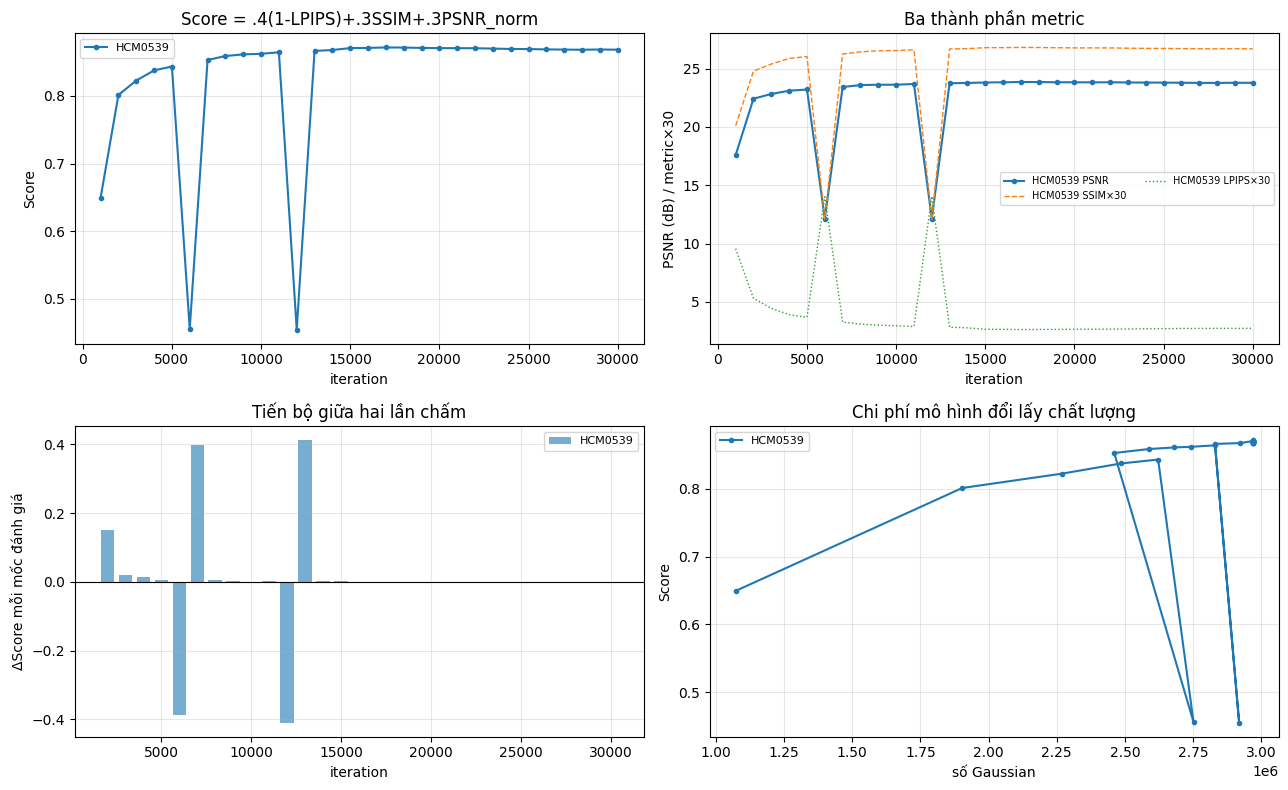

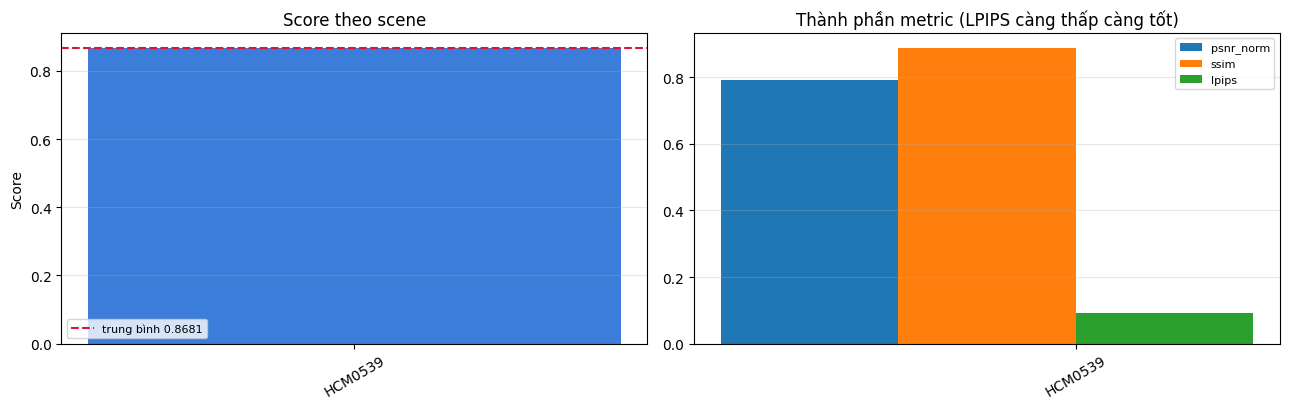

In [7]:
history, board = run.analytics(cfg, results, submissions)
display(board)

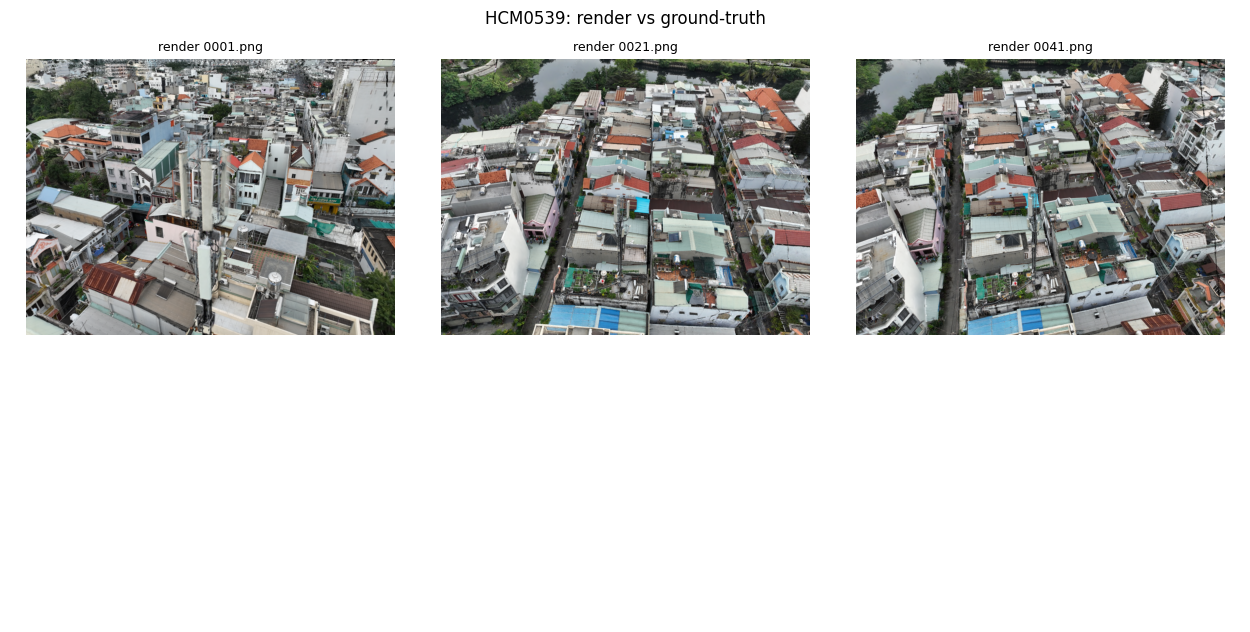

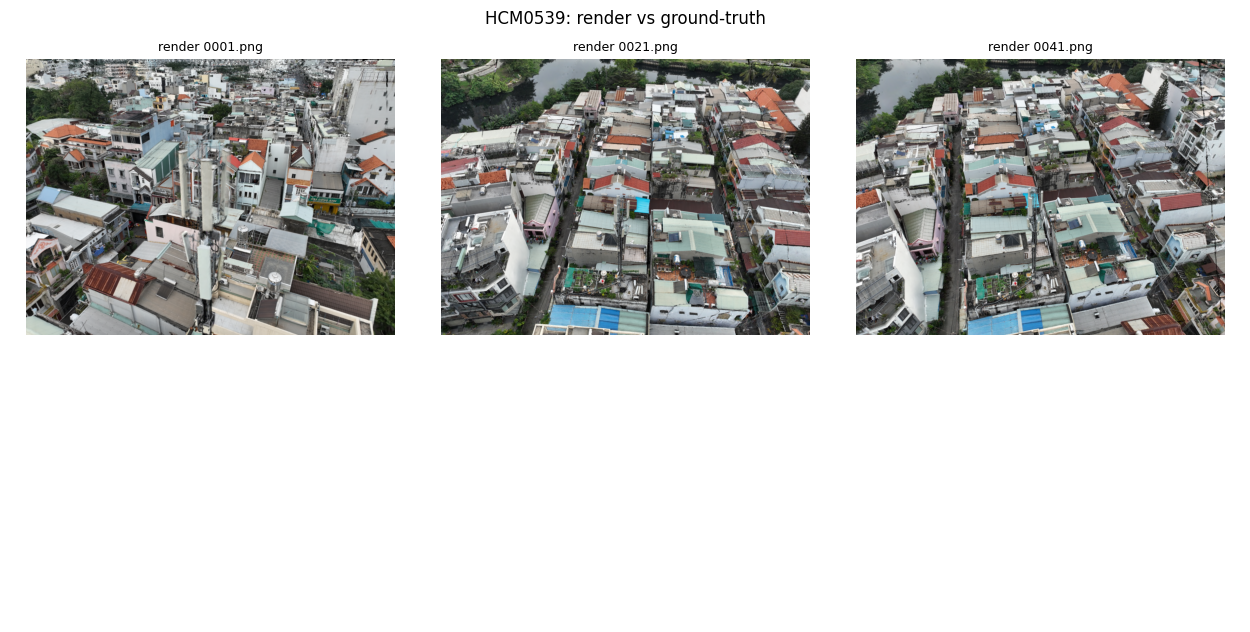

In [8]:
report.show_samples(cfg, scenes[0], n=3)      # renders next to ground truth

## 7 — Build `submission.zip` and download it

```
submission.zip
├── <scene>/0001.png, 0002.png, ...
└── ...
```

Test camera lấy từ **`test/test_poses.csv`** của ban tổ chức: đúng 60 pose, render đúng
`width`×`height` ghi trong file, đánh số theo thứ tự dòng (`submission_order="csv"`).
Scene nào không có CSV thì quay về cách cũ (`llffhold`).

`run.finish` nén ảnh, rồi **đối chiếu thẳng với CSV**: đủ số pose chưa, kích thước ảnh có
khớp không, tên file có liên tục không. Với `save_to_drive=True` mọi thứ đã nằm trên Drive
trước khi tải, nên trình duyệt chặn tải cũng không mất gì.

In [9]:
check, problems = run.finish(cfg, scenes)
display(check)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,scene,images,width,height,expected
0,HCM0539,60,1320,989,60
